In [3]:
!pip install -q ultralytics transformers accelerate pillow matplotlib bitsandbytes

import os, glob, shutil, time, json, random, gc, warnings, zipfile
import numpy as np, pandas as pd, torch, yaml, cv2
from google.colab import drive
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

root_dir    = '/content/drive/MyDrive/road_crack_detection'
out_dir     = os.path.join(root_dir, 'yolo26s_strip_vlm')
best_path   = os.path.join(root_dir, 'yolo26s_strip', 'train_run', 'weights', 'best.pt')
zip_path    = os.path.join(root_dir, 'dataaaa.zip')
gradcam_dir = os.path.join(out_dir, 'gradcam')
vlm_dir     = os.path.join(out_dir, 'vlm')
for d in (out_dir, gradcam_dir, vlm_dir):
    os.makedirs(d, exist_ok=True)

# Extract the test zip to local Colab storage (the next cells read from test_src)
test_src = '/content/testdata_extracted'
if os.path.isfile(zip_path) and zipfile.is_zipfile(zip_path):
    if os.path.exists(test_src):
        shutil.rmtree(test_src)
    os.makedirs(test_src, exist_ok=True)
    print(f'Extracting {zip_path} ...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(test_src)
    print('Extraction complete.')
elif os.path.isdir(zip_path):
    print('dataaaa.zip is a folder, using it directly.')
    test_src = zip_path
else:
    raise FileNotFoundError(f'Could not find a valid zip file or folder at {zip_path}')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)
print('best.pt found       :', os.path.exists(best_path))
print('data.yaml found     :', any('data.yaml' in f for _, _, f in os.walk(test_src)))
print('Outputs will go to  :', out_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting /content/drive/MyDrive/road_crack_detection/dataaaa.zip ...
Extraction complete.
Device: cuda
best.pt found       : True
data.yaml found     : True
Outputs will go to  : /content/drive/MyDrive/road_crack_detection/yolo26s_strip_vlm


In [4]:
import torch.nn as nn

class StripConvBlock(nn.Module):
    def __init__(self, c, k=11):
        super().__init__()
        p = k // 2
        self.dw_local = nn.Conv2d(c, c, 3, padding=1, groups=c, bias=False)
        self.dw_h = nn.Conv2d(c, c, (1, k), padding=(0, p), groups=c, bias=False)
        self.dw_v = nn.Conv2d(c, c, (k, 1), padding=(p, 0), groups=c, bias=False)
        self.bn = nn.BatchNorm2d(c)
        self.act = nn.SiLU()
        self.pw = nn.Conv2d(c, c, 1, bias=False)
        nn.init.zeros_(self.pw.weight)

    def forward(self, x):
        y = self.dw_local(x) + self.dw_h(x) + self.dw_v(x)
        return x + self.pw(self.act(self.bn(y)))


class NeckStrip(nn.Module):
    def __init__(self, base, c, k):
        super().__init__()
        self.base = base
        self.strip = StripConvBlock(c, k)
        self.f, self.i, self.type, self.np = base.f, base.i, base.type, base.np

    def forward(self, x):
        return self.strip(self.base(x))

print('Strip modules defined.')

Strip modules defined.


In [5]:
# CELL 1b: fix the class names stored inside best.pt (ids 2 and 3 were named the wrong way round)
import torch, os
from ultralytics import YOLO

ckpt = torch.load(best_path, map_location='cpu', weights_only=False)
NEW_NAMES = {0: 'Longitudinal Crack', 1: 'Transverse Crack', 2: 'Alligator Crack', 3: 'Pothole'}

for k in ('model', 'ema'):
    if ckpt.get(k) is not None:
        print(k, 'old names:', ckpt[k].names)
        ckpt[k].names = NEW_NAMES

patched = os.path.join(os.path.dirname(best_path), 'best_fixednames.pt')
torch.save(ckpt, patched)
best_path = patched
print('Using:', best_path)
print('Names now:', YOLO(best_path).names)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
model old names: {0: 'Longitudinal Crack', 1: 'Transverse Crack', 2: 'Pothole', 3: 'Alligator Crack'}
Using: /content/drive/MyDrive/road_crack_detection/yolo26s_strip/train_run/weights/best_fixednames.pt
Names now: {0: 'Longitudinal Crack', 1: 'Transverse Crack', 2: 'Alligator Crack', 3: 'Pothole'}


In [6]:
local_test = '/content/testdata'
shutil.copytree(test_src, local_test, dirs_exist_ok=True)

# Show structure
for r, d, f in os.walk(local_test):
    depth = r.replace(local_test, '').count(os.sep)
    if depth <= 3:
        print('  ' * depth + os.path.basename(r) + '/', f'({len(f)} files)')

yaml_path = next(os.path.join(r, 'data.yaml') for r, _, f in os.walk(local_test) if 'data.yaml' in f)
dataset_root = os.path.dirname(yaml_path)

img_dirs = [r for r, _, _ in os.walk(dataset_root) if os.path.basename(r) == 'images']
test_like = [d for d in img_dirs if 'test' in d.lower()]
test_img_dir = test_like[0] if test_like else img_dirs[0]
if len(img_dirs) > 1 and not test_like:
    print('WARNING: several images folders found, using the first:', img_dirs)
print('Test images folder:', test_img_dir)

CLASS_NAMES = {0: 'Longitudinal Crack', 1: 'Transverse Crack', 2: 'Alligator Crack', 3: 'Pothole'}

with open(yaml_path) as f:
    cfg = yaml.safe_load(f)
cfg['path'] = dataset_root
# Ultralytics requires train/val keys to exist; they are pointed at the test folder only to satisfy that check.
cfg['train'] = cfg['val'] = cfg['test'] = test_img_dir
cfg['nc'] = 4
cfg['names'] = CLASS_NAMES
with open(yaml_path, 'w') as f:
    yaml.dump(cfg, f)
test_data_yaml = yaml_path

exts = ('*.jpg', '*.jpeg', '*.png', '*.bmp')
test_files = sorted(sum([glob.glob(os.path.join(test_img_dir, e)) for e in exts], []))
label_dir = os.path.join(os.path.dirname(test_img_dir), 'labels')

counts = {k: 0 for k in range(10)}
for lp in glob.glob(os.path.join(label_dir, '*.txt')):
    for line in open(lp):
        if line.strip():
            counts[int(float(line.split()[0]))] += 1

print(f'Test images: {len(test_files)}')
print('Instances per class id:', {k: v for k, v in counts.items() if v})
if any(counts[k] for k in range(4, 10)):
    print('WARNING: label ids outside 0-3 found. Check the class order of this dataset.')

testdata/ (0 files)
  dataaaa.zip/ (3 files)
    valid/ (0 files)
      labels/ (1100 files)
      images/ (1100 files)
    test/ (0 files)
      labels/ (1976 files)
      images/ (1976 files)
    train/ (0 files)
      labels/ (5872 files)
      images/ (5872 files)
Test images folder: /content/testdata/dataaaa.zip/valid/images
Test images: 1100
Instances per class id: {0: 967, 1: 360, 2: 294, 3: 176}


In [7]:
from ultralytics import YOLO
from ultralytics.utils.torch_utils import get_flops

best_model = YOLO(best_path)
n_params = sum(p.numel() for p in best_model.model.parameters())

t0 = time.time()
m = best_model.val(data=test_data_yaml, split='test', imgsz=640, plots=True,
                   project=out_dir, name='test_eval', exist_ok=True)
wall = time.time() - t0

mean_p, mean_r = float(np.mean(m.box.p)), float(np.mean(m.box.r))
map50, map5095 = float(m.box.map50), float(m.box.map)
try:
    gflops = get_flops(best_model.model, 640)
except Exception:
    gflops = float('nan')
infer_ms = m.speed['inference']

print('--- TEST SET RESULTS ---')
print(f'Precision {mean_p:.4f} | Recall {mean_r:.4f} | mAP@50 {map50:.4f} | mAP@50-95 {map5095:.4f}')
print(f'Inference {infer_ms:.1f} ms/img | Params {n_params/1e6:.2f}M | GFLOPs {gflops:.1f}')

rows = []
for j, ci in enumerate(m.box.ap_class_index):
    rows.append({'Class': m.names[int(ci)], 'Precision': float(m.box.p[j]), 'Recall': float(m.box.r[j]),
                 'AP@50': float(m.box.ap50[j]), 'AP@50-95': float(m.box.ap[j])})
class_df = pd.DataFrame(rows)
print(class_df.round(4).to_string(index=False))

val_ref = {'Mean_Precision': 0.8340, 'Mean_Recall': 0.8474, 'mAP@50': 0.9069, 'mAP@50-95': 0.5465}
scores_df = pd.DataFrame({
    'Metric': ['Mean_Precision', 'Mean_Recall', 'mAP@50', 'mAP@50-95',
               'Inference_ms_per_image', 'Params_M', 'GFLOPs', 'Eval_Wall_Time_Sec'],
    'Test': [mean_p, mean_r, map50, map5095, infer_ms, n_params/1e6, gflops, wall],
})
scores_df['Validation_reference'] = scores_df['Metric'].map(val_ref)
scores_df.to_csv(os.path.join(out_dir, 'test_evaluation_scores.csv'), index=False)
class_df.to_csv(os.path.join(out_dir, 'test_class_scores.csv'), index=False)
print('Saved to', out_dir, '(plots and confusion matrix are in test_eval/)')

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 138 layers, 9,836,264 parameters, 0 gradients, 21.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1315.3±512.8 MB/s, size: 52.7 KB)
val: Scanning /content/testdata/dataaaa.zip/valid/labels... 1100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1100/1100 623.9it/s 1.8s
val: New cache created: /content/testdata/dataaaa.zip/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 3.0it/s 22.7s
                   all       1100       1797      0.834      0.847      0.907      0.546
    Longitudinal Crack        653        967      0.833      0.834      0.903      0.575
      Transverse Crack        293        360      0.814      0.814      0.878      0.524
       Alligator Crack        266        294       0.88      0.873       0.94      0.595
               Pothole        158        176     

In [8]:
# CELL A: original class list + label id counts
import os, glob
from collections import Counter

orig_yaml = next(os.path.join(r, 'data.yaml') for r, _, f in os.walk(test_src) if 'data.yaml' in f)
print(open(orig_yaml).read())

cnt = Counter()
for lp in glob.glob(os.path.join(label_dir, '*.txt')):
    for line in open(lp):
        if line.strip():
            cnt[int(float(line.split()[0]))] += 1
print('Instances per label id:', sorted(cnt.items()))

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 4
names: ['0', '1', '2', '3']

roboflow:
  workspace: rdd-u23ar
  project: rdd-59irl
  version: 3
  license: CC BY 4.0
  url: https://universe.roboflow.com/rdd-u23ar/rdd-59irl/dataset/3
Instances per label id: [(0, 967), (1, 360), (2, 294), (3, 176)]


In [9]:
# CELL 4: pick sample images per class
CONF = 0.25
N_PER_CLASS = 5          # increase for more examples
rng = random.Random(42)

def read_labels(img_path):
    stem = os.path.splitext(os.path.basename(img_path))[0]
    lp = os.path.join(label_dir, stem + '.txt')
    out = []
    if os.path.exists(lp):
        for line in open(lp):
            p = line.split()
            if len(p) >= 5:
                c = int(float(p[0])); v = list(map(float, p[1:]))
                if len(v) == 4:
                    xc, yc, bw, bh = v
                else:   # polygon labels -> bounding box
                    pts = np.array(v).reshape(-1, 2)
                    x0, y0 = pts.min(0); x1, y1 = pts.max(0)
                    xc, yc, bw, bh = (x0+x1)/2, (y0+y1)/2, x1-x0, y1-y0
                out.append((c, xc, yc, bw, bh))
    return out

samples, seen = [], set()
for c, cname in CLASS_NAMES.items():
    cands = [p for p in test_files if any(l[0] == c for l in read_labels(p))]
    for p in rng.sample(cands, min(N_PER_CLASS, len(cands))):
        if p not in seen:
            seen.add(p); samples.append((cname, p))
print(f'{len(samples)} sample images selected')

20 sample images selected


In [10]:
# CELL B: which class does the model predict for each test label id?
import os, glob, random
import numpy as np, pandas as pd
from ultralytics import YOLO

def iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / ua if ua > 0 else 0

pred_model = YOLO(best_path)
mat = np.zeros((5, 5), int)          # rows: test label id 0-4 | cols: model class 0-3, then "missed"
sub = random.Random(0).sample(test_files, min(500, len(test_files)))

for p in sub:
    gts = read_labels(p)
    if not gts:
        continue
    r = pred_model.predict(p, conf=0.25, imgsz=640, verbose=False)[0]
    pb = r.boxes.xyxyn.cpu().numpy()
    pc = r.boxes.cls.cpu().numpy().astype(int)
    for cid, xc, yc, bw, bh in gts:
        if cid > 4:
            continue
        g = (xc - bw/2, yc - bh/2, xc + bw/2, yc + bh/2)
        best, bc = 0, None
        for b, k in zip(pb, pc):
            v = iou(g, b)
            if v > best:
                best, bc = v, k
        mat[cid, bc if best >= 0.3 else 4] += 1

cols = [CLASS_NAMES[i] for i in range(4)] + ['missed']
df_map = pd.DataFrame(mat, index=[f'test id {i}' for i in range(5)], columns=cols)
print(df_map)
print()
print((df_map.div(df_map.sum(1).replace(0, 1), axis=0) * 100).round(0))

           Longitudinal Crack  Transverse Crack  Alligator Crack  Pothole  \
test id 0                 426                 0                5        0   
test id 1                   1               136                0        0   
test id 2                   4                 1              119        0   
test id 3                   0                 0                0       75   
test id 4                   0                 0                0        0   

           missed  
test id 0      32  
test id 1      15  
test id 2       3  
test id 3       6  
test id 4       0  

           Longitudinal Crack  Transverse Crack  Alligator Crack  Pothole  \
test id 0                92.0               0.0              1.0      0.0   
test id 1                 1.0              89.0              0.0      0.0   
test id 2                 3.0               1.0             94.0      0.0   
test id 3                 0.0               0.0              0.0     93.0   
test id 4                 0.0  

In [11]:
# CELL C: drop the extra class id 4, rebuild the test set, re-evaluate
import os, glob, shutil, yaml
import numpy as np
from ultralytics import YOLO

best_model = YOLO(best_path)

MAP = {0: 0, 1: 1, 2: 2, 3: 3, 4: None}     # {test id: training id}; None = class the model was not trained on

fixed = '/content/test_fixed'
shutil.rmtree(fixed, ignore_errors=True)
os.makedirs(f'{fixed}/test/images')
os.makedirs(f'{fixed}/test/labels')

kept = skipped = 0
for ip in test_files:
    stem = os.path.splitext(os.path.basename(ip))[0]
    lp = os.path.join(label_dir, stem + '.txt')
    out, has_unmapped = [], False
    if os.path.exists(lp):
        for line in open(lp):
            p = line.split()
            if len(p) < 5:
                continue
            nc = MAP.get(int(float(p[0])))
            if nc is None:
                has_unmapped = True
            else:
                out.append(' '.join([str(nc)] + p[1:]))
    if has_unmapped:
        skipped += 1
        continue
    shutil.copy(ip, f'{fixed}/test/images/')
    open(f'{fixed}/test/labels/{stem}.txt', 'w').write('\n'.join(out))
    kept += 1
print(f'kept {kept} images, skipped {skipped} (contain unmapped classes)')

with open(f'{fixed}/data.yaml', 'w') as f:
    yaml.dump({'path': fixed, 'train': 'test/images', 'val': 'test/images', 'test': 'test/images',
               'nc': 4, 'names': CLASS_NAMES}, f)

m = best_model.val(data=f'{fixed}/data.yaml', split='test', imgsz=640, plots=True,
                   project=out_dir, name='test_eval_fixed', exist_ok=True)
print(f'Precision {np.mean(m.box.p):.4f} | Recall {np.mean(m.box.r):.4f} | '
      f'mAP@50 {m.box.map50:.4f} | mAP@50-95 {m.box.map:.4f}')
for j, ci in enumerate(m.box.ap_class_index):
    print(f'{m.names[int(ci)]:20s} P {m.box.p[j]:.3f} R {m.box.r[j]:.3f} AP50 {m.box.ap50[j]:.3f}')

# point the later cells (Grad-CAM / VLM sampling) at the corrected data
test_img_dir = f'{fixed}/test/images'
label_dir = f'{fixed}/test/labels'
test_data_yaml = f'{fixed}/data.yaml'
test_files = sorted(glob.glob(os.path.join(test_img_dir, '*.*')))

kept 1100 images, skipped 0 (contain unmapped classes)
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 138 layers, 9,836,264 parameters, 0 gradients, 21.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1862.4±690.3 MB/s, size: 85.1 KB)
val: Scanning /content/test_fixed/test/labels... 1100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1100/1100 1.9Kit/s 0.6s
val: New cache created: /content/test_fixed/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 3.3it/s 21.2s
                   all       1100       1797      0.834      0.847      0.907      0.546
    Longitudinal Crack        653        967      0.833      0.834      0.903      0.575
      Transverse Crack        293        360      0.814      0.814      0.878      0.524
       Alligator Crack        266        294       0.88      0.873       0.94      0.595
               Po

In [12]:
# CELL 4 (RE-RUN after Cell C so samples use the corrected labels)
CONF = 0.25
N_PER_CLASS = 5          # increase for more examples
rng = random.Random(42)

def read_labels(img_path):
    stem = os.path.splitext(os.path.basename(img_path))[0]
    lp = os.path.join(label_dir, stem + '.txt')
    out = []
    if os.path.exists(lp):
        for line in open(lp):
            p = line.split()
            if len(p) >= 5:
                c = int(float(p[0])); v = list(map(float, p[1:]))
                if len(v) == 4:
                    xc, yc, bw, bh = v
                else:   # polygon labels -> bounding box
                    pts = np.array(v).reshape(-1, 2)
                    x0, y0 = pts.min(0); x1, y1 = pts.max(0)
                    xc, yc, bw, bh = (x0+x1)/2, (y0+y1)/2, x1-x0, y1-y0
                out.append((c, xc, yc, bw, bh))
    return out

samples, seen = [], set()
for c, cname in CLASS_NAMES.items():
    cands = [p for p in test_files if any(l[0] == c for l in read_labels(p))]
    for p in rng.sample(cands, min(N_PER_CLASS, len(cands))):
        if p not in seen:
            seen.add(p); samples.append((cname, p))
print(f'{len(samples)} sample images selected')

20 sample images selected


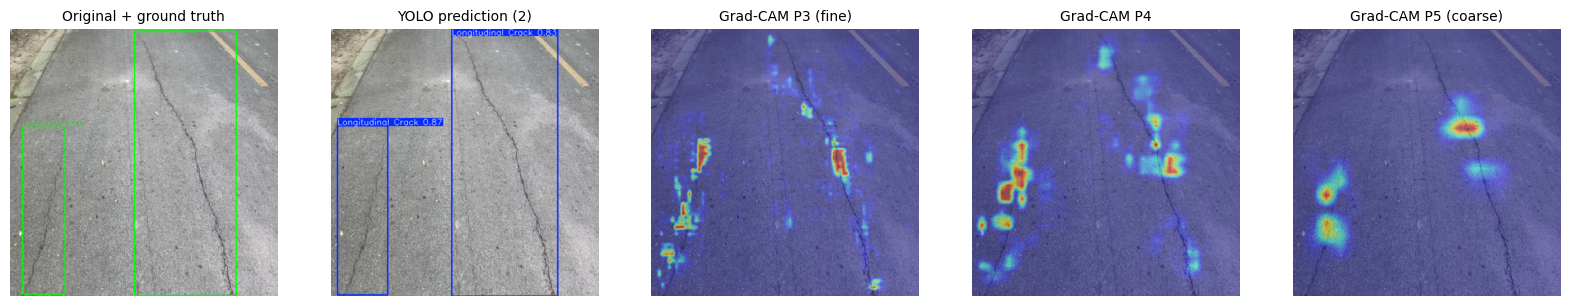

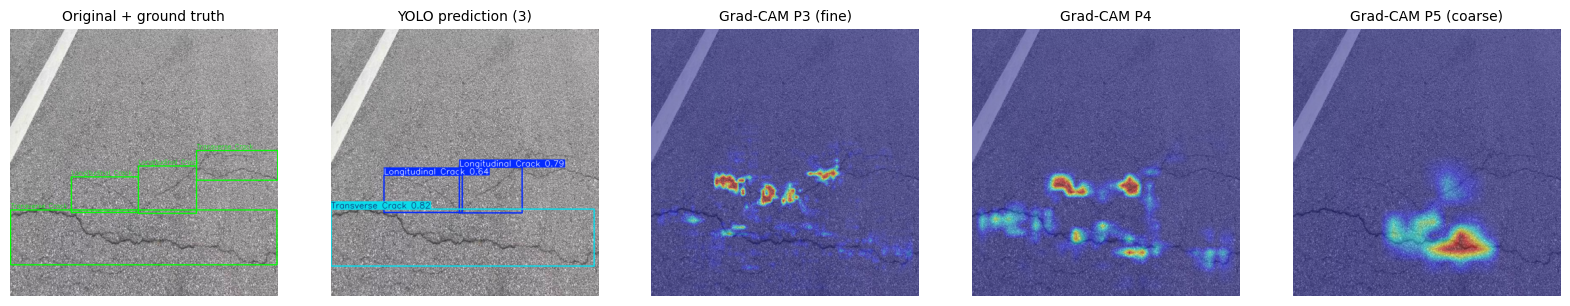

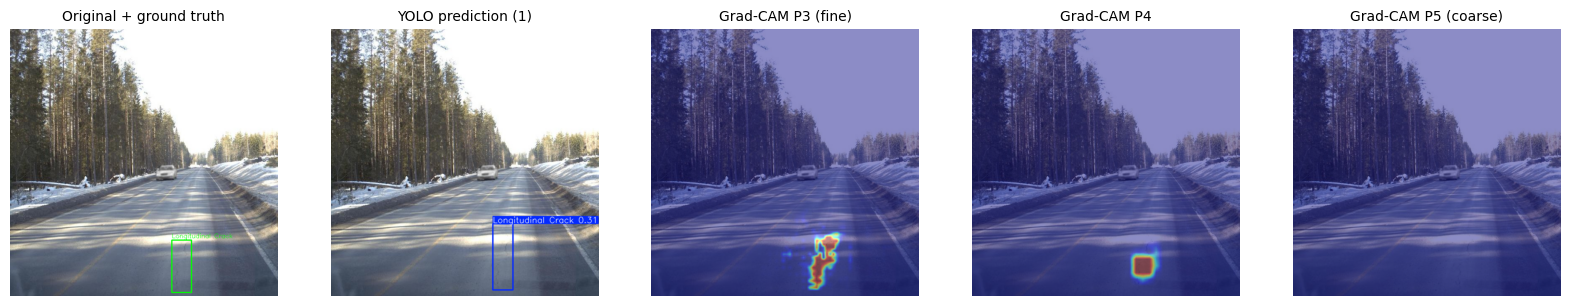

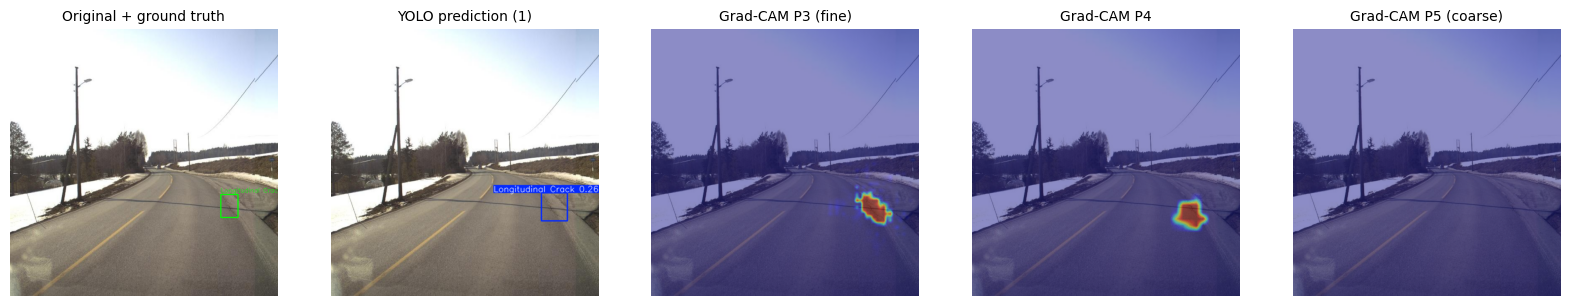

Grad-CAM figures saved to /content/drive/MyDrive/road_crack_detection/yolo26s_strip_vlm/gradcam


In [13]:
import matplotlib.pyplot as plt

LAYER_NAMES = {16: 'P3 (fine)', 19: 'P4', 22: 'P5 (coarse)'}
STRIDES = {16: 8, 19: 16, 22: 32}

class YoloGradCAM:
    def __init__(self, weights, layer_ids=(16, 19, 22), imgsz=640):
        self.imgsz = imgsz
        self.layer_ids = layer_ids
        self.net = YOLO(weights).model.float().to(device).eval()
        self.acts, self.grads = {}, {}
        for i in layer_ids:
            self.net.model[i].register_forward_hook(self._make_hook(i))

    def _make_hook(self, i):
        def hook(module, inp, out):
            self.acts[i] = out
            if out.requires_grad:
                out.register_hook(lambda g, i=i: self.grads.__setitem__(i, g))
        return hook

    def _letterbox(self, bgr):
        h, w = bgr.shape[:2]
        r = min(self.imgsz / h, self.imgsz / w)
        nw, nh = int(round(w * r)), int(round(h * r))
        dw, dh = (self.imgsz - nw) / 2, (self.imgsz - nh) / 2
        img = cv2.resize(bgr, (nw, nh), interpolation=cv2.INTER_LINEAR)
        top, bottom = int(round(dh - 0.1)), int(round(dh + 0.1))
        left, right = int(round(dw - 0.1)), int(round(dw + 0.1))
        img = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=(114, 114, 114))
        return img, (top, left, nh, nw)

    @staticmethod
    def _scores(out):
        tensors = []
        def walk(o):
            if torch.is_tensor(o): tensors.append(o)
            elif isinstance(o, (list, tuple)): [walk(x) for x in o]
            elif isinstance(o, dict): [walk(x) for x in o.values()]
        walk(out)
        for t in tensors:
            if t.dim() == 3 and t.shape[-1] == 6:        # end-to-end: [B, N, 6] (x1,y1,x2,y2,score,cls)
                return t[0, :, 4]
        for t in tensors:
            if t.dim() == 3 and t.shape[1] == 4 + len(CLASS_NAMES):   # dense: [B, 4+nc, N]
                return t[0, 4:, :].max(0).values
        raise RuntimeError(f'Unrecognised output shapes: {[tuple(t.shape) for t in tensors]}')

    def __call__(self, bgr, conf=0.25, border_px=16):
        h, w = bgr.shape[:2]
        lb, (top, left, nh, nw) = self._letterbox(bgr)
        x = torch.from_numpy(cv2.cvtColor(lb, cv2.COLOR_BGR2RGB)).permute(2, 0, 1).float().div(255)[None].to(device)
        x.requires_grad_(True)
        self.acts.clear(); self.grads.clear()
        self.net.zero_grad(set_to_none=True)
        with torch.enable_grad():
            out = self.net(x)
            scores = self._scores(out)
            keep = scores >= conf
            target = scores[keep].sum() if keep.any() else scores.max()
            if not target.requires_grad:
                raise RuntimeError('Output is not differentiable; the head output needs a different target.')
            target.backward()
        cams = {}
        for i in self.layer_ids:
            g, a = self.grads.get(i), self.acts[i]
            if g is None:
                cams[i] = None
                continue
            # HiResCAM: element-wise gradient * activation keeps the location
            cam = torch.relu((g * a).sum(1))[0].detach().cpu().numpy().astype(np.float32)
            # remove border artifacts (~16 input px, converted to cells for this stride)
            b = int(np.ceil(border_px / STRIDES[i]))
            cam[:b, :] = 0; cam[-b:, :] = 0; cam[:, :b] = 0; cam[:, -b:] = 0
            # clip hot outliers
            hi = np.percentile(cam, 99.5)
            if hi > 0:
                cam = np.clip(cam, 0, hi)
            cam = cv2.resize(cam, (self.imgsz, self.imgsz))[top:top + nh, left:left + nw]
            cam = cv2.resize(cam, (w, h))
            cams[i] = cam / (cam.max() + 1e-8)
        self.acts.clear(); self.grads.clear()
        return cams, int(keep.sum())


def overlay(bgr, cam, alpha=0.45):
    heat = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    return cv2.addWeighted(bgr, 1 - alpha, heat, alpha, 0)

def where(box, W, H):
    x1, y1, x2, y2 = box
    cx, cy = (x1 + x2) / 2 / W, (y1 + y2) / 2 / H
    v = 'top' if cy < 1/3 else 'bottom' if cy > 2/3 else 'middle'
    h = 'left' if cx < 1/3 else 'right' if cx > 2/3 else 'center'
    return f'{v}-{h}'

cam_engine = YoloGradCAM(best_path)
pred_model = YOLO(best_path)      # separate copy for normal prediction

def process_image(img, tag, labels=None, conf=CONF, show=False):
    H, W = img.shape[:2]
    res = pred_model.predict(img, conf=conf, imgsz=640, verbose=False)[0]
    dets = []
    for b in res.boxes:
        x1, y1, x2, y2 = [float(v) for v in b.xyxy[0]]
        dets.append({'class': res.names[int(b.cls)], 'conf': float(b.conf),
                     'box': [round(v, 1) for v in (x1, y1, x2, y2)],
                     'position': where((x1, y1, x2, y2), W, H),
                     'area_pct': 100 * (x2 - x1) * (y2 - y1) / (W * H)})
    cams, n_keep = cam_engine(img, conf=conf)

    gt_img = img.copy()
    if labels:
        for c, xc, yc, bw, bh in labels:
            p1 = (int((xc - bw/2) * W), int((yc - bh/2) * H)); p2 = (int((xc + bw/2) * W), int((yc + bh/2) * H))
            cv2.rectangle(gt_img, p1, p2, (0, 255, 0), 2)
            cv2.putText(gt_img, CLASS_NAMES.get(c, str(c)), (p1[0], max(p1[1] - 5, 12)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    panels = [('Original' + (' + ground truth' if labels else ''), gt_img),
              (f'YOLO prediction ({len(dets)})', res.plot())]
    for lid, nm in LAYER_NAMES.items():
        if cams.get(lid) is not None:
            panels.append((f'Grad-CAM {nm}', overlay(img, cams[lid])))

    fig, axes = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4))
    for ax, (title, im) in zip(np.atleast_1d(axes), panels):
        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); ax.set_title(title, fontsize=10); ax.axis('off')
    fig_path = os.path.join(gradcam_dir, f'{tag}.png')
    fig.savefig(fig_path, dpi=130, bbox_inches='tight')
    if show: plt.show()
    plt.close(fig)
    return {'tag': tag, 'dets': dets, 'figure': fig_path, 'no_detection': n_keep == 0}


records = []
for k, (cname, p) in enumerate(samples):
    img = cv2.imread(p)
    rec = process_image(img, f'{k:02d}_{cname.replace(" ", "_")}', labels=read_labels(p), show=(k < 4))
    rec.update({'image': p, 'sample_class': cname})
    records.append(rec)
print(f'Grad-CAM figures saved to {gradcam_dir}')

In [14]:
from PIL import Image
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

cam_engine.acts.clear(); cam_engine.grads.clear()
gc.collect(); torch.cuda.empty_cache()

if 'vlm' not in globals():
    VLM_ID = 'Qwen/Qwen2-VL-7B-Instruct'
    vlm = Qwen2VLForConditionalGeneration.from_pretrained(
        VLM_ID, device_map='auto',
        quantization_config=BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16))
    processor = AutoProcessor.from_pretrained(VLM_ID, min_pixels=256*28*28, max_pixels=640*28*28)
    vlm.eval()
else:
    print('VLM already loaded, skipping reload.')

# ---- Severity from rules (starting thresholds: tune and state them in the thesis)
def rule_severity(d, W, H):
    x1, y1, x2, y2 = d['box']
    extent = 100 * max((x2 - x1) / W, (y2 - y1) / H)
    area = d['area_pct']
    if d['class'] == 'Pothole':
        return 'high' if area >= 5 else 'medium' if area >= 1 else 'low'
    if d['class'] == 'Alligator Crack':
        return 'high' if area >= 10 else 'medium'
    return 'high' if extent >= 60 else 'medium' if extent >= 25 else 'low'

SEV_ORDER = {'none': 0, 'low': 1, 'medium': 2, 'high': 3}

def overall_severity(dets, W, H):
    if not dets:
        return 'none'
    return max((rule_severity(d, W, H) for d in dets), key=SEV_ORDER.get)

# ---- Deterministic generation helper
def _generate(pil, prompt, max_new_tokens=160):
    messages = [{'role': 'user', 'content': [{'type': 'image'}, {'type': 'text', 'text': prompt}]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[pil], return_tensors='pt').to(vlm.device)
    with torch.no_grad():
        out = vlm.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, repetition_penalty=1.05)
    return processor.batch_decode(out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0].strip()

# ---- Pass A: blind look (no detector info)
BLIND_PROMPT = ('Look at this road image. Which ONE best describes the main damage: '
                'longitudinal crack, transverse crack, pothole, alligator crack, or none? '
                'Answer with that label, then one short sentence describing what you see.')

KEYWORDS = {'Longitudinal Crack': ['longitudinal'], 'Transverse Crack': ['transverse'],
            'Pothole': ['pothole'], 'Alligator Crack': ['alligator', 'fatigue', 'crocodile']}

# ---- Pass B: explanation, detector output marked as unverified, severity fixed
def build_prompt(dets, severity):
    ds = sorted(dets, key=lambda d: d['area_pct'], reverse=True)[:6]
    lines = '\n'.join(f"- {d['class']} (conf {d['conf']:.2f}), {d['position']}, {d['area_pct']:.1f}% of image"
                      for d in ds) or '- nothing detected'
    return ('Inspect this road image. An automatic detector, which may be wrong, reported (largest first):\n'
            f'{lines}\n'
            f'Severity, computed from detection size by fixed rules: {severity}. Use it as given; do not change it.\n\n'
            'Answer in three short lines:\n'
            '1. Visible damage (type, rough size, location):\n'
            '2. Detector check: agree or disagree with each detection, and name anything it missed:\n'
            f'3. Recommended action (one sentence, consistent with {severity} severity):')

def vlm_describe(img_path, dets):
    pil = Image.open(img_path).convert('RGB')
    W, H = pil.size
    severity = overall_severity(dets, W, H)
    blind = _generate(pil, BLIND_PROMPT, max_new_tokens=60)
    explanation = _generate(pil, build_prompt(dets, severity), max_new_tokens=180)
    if dets:
        main = max(dets, key=lambda d: d['area_pct'])['class']
        agrees = any(k in blind.lower() for k in KEYWORDS.get(main, []))
    else:
        main, agrees = 'none', 'none' in blind.lower()
    return {'severity_rule': severity, 'main_detection': main, 'vlm_blind': blind,
            'vlm_agrees_with_yolo': bool(agrees), 'vlm_explanation': explanation}

print('VLM loaded.')

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.5k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

VLM loaded.


In [15]:
vlm_rows = []
for rec in records:
    t0 = time.time()
    rec.update(vlm_describe(rec['image'], rec['dets']))
    vlm_rows.append({
        'image': os.path.basename(rec['image']),
        'sample_class': rec['sample_class'],
        'yolo_detections': '; '.join(f"{d['class']} {d['conf']:.2f}" for d in rec['dets']) or 'none',
        'severity_rule': rec['severity_rule'],
        'vlm_blind': rec['vlm_blind'],
        'vlm_agrees_with_yolo': rec['vlm_agrees_with_yolo'],
        'vlm_explanation': rec['vlm_explanation'],
        'gradcam_figure': rec['figure'],
    })
    print(f"[{rec['tag']}] {time.time() - t0:.1f}s | severity (rules): {rec['severity_rule']} | agrees: {rec['vlm_agrees_with_yolo']}")
    print('  YOLO :', vlm_rows[-1]['yolo_detections'])
    print('  BLIND:', rec['vlm_blind'])
    print('  VLM  :', rec['vlm_explanation'].replace('\n', '\n         '), '\n')

df = pd.DataFrame(vlm_rows)
df.to_csv(os.path.join(vlm_dir, 'vlm_descriptions.csv'), index=False)
with open(os.path.join(vlm_dir, 'vlm_descriptions.json'), 'w') as f:
    json.dump(records, f, indent=2, default=str)
print(f"VLM blind answer agreed with YOLO's main detection on {df['vlm_agrees_with_yolo'].mean():.0%} of samples")
print('Saved VLM outputs to', vlm_dir)

[00_Longitudinal_Crack] 9.5s | severity (rules): high | agrees: True
  YOLO : Longitudinal Crack 0.87; Longitudinal Crack 0.83
  BLIND: Longitudinal crack
  VLM  : 1. Visible damage (type, rough size, location): Longitudinal crack, large, middle-center.
         2. Detector check: Agree with the detections. No other significant damage is visible.
         3. Recommended action: Repair the longitudinal crack immediately to prevent further deterioration. 

[01_Longitudinal_Crack] 9.0s | severity (rules): high | agrees: False
  YOLO : Transverse Crack 0.82; Longitudinal Crack 0.79; Longitudinal Crack 0.64
  BLIND: Longitudinal crack
  VLM  : 1. Visible damage (type, rough size, location): Transverse Crack (20.9%), bottom-center.
         2. Detector check: Agree with the Transverse Crack detection but disagree with the Longitudinal Crack detections as they are not present.
         3. Recommended action: Repair the Transverse Crack immediately to prevent further damage. 

[02_Longitudinal

In [16]:
import requests

def analyze(source, name='custom'):
    if source.startswith('http'):
        r = requests.get(source, timeout=30, headers={'User-Agent': 'Mozilla/5.0'}); r.raise_for_status()
        img = cv2.imdecode(np.frombuffer(r.content, np.uint8), cv2.IMREAD_COLOR)
    else:
        img = cv2.imread(source)
    assert img is not None, 'Could not read the image'
    path = os.path.join(out_dir, f'{name}_input.jpg'); cv2.imwrite(path, img)
    rec = process_image(img, f'{name}_gradcam', show=True)
    rec.update(vlm_describe(path, rec['dets']))
    print('YOLO    :', [(d['class'], round(d['conf'], 2)) for d in rec['dets']] or 'no detections')
    print('Severity:', rec['severity_rule'], '(rule-based)')
    print('VLM     :', rec['vlm_blind'], '| agrees with YOLO:', rec['vlm_agrees_with_yolo'])
    print(rec['vlm_explanation'])
    return rec

# analyze('https://example.com/road.jpg')

In [17]:
from google.colab import files
uploaded = files.upload()
print(list(uploaded.keys()))

Saving pothole-getty-images.jpg to pothole-getty-images.jpg
['pothole-getty-images.jpg']


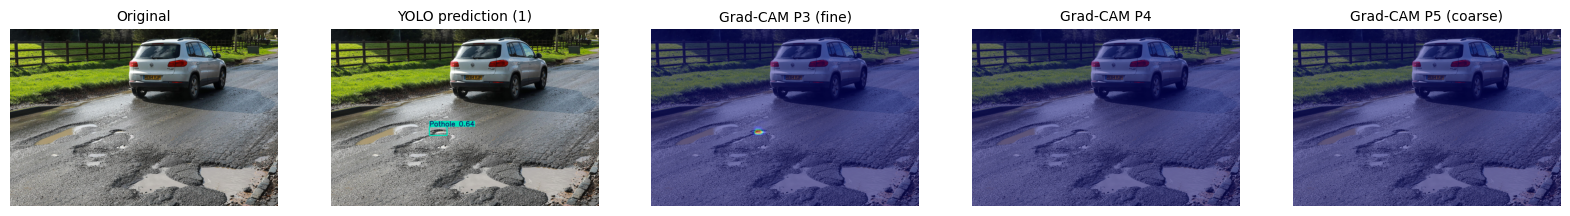

YOLO    : [('Pothole', 0.64)]
Severity: low (rule-based)
VLM     : Pothole - The road has large potholes filled with water. | agrees with YOLO: True
1. Pothole (rough size: small, location: middle-center)
2. Agree with the detection.
3. Monitor the pothole for further deterioration.


{'tag': 'pothole_test_gradcam',
 'dets': [{'class': 'Pothole',
   'conf': 0.6427669525146484,
   'box': [440.8, 440.1, 519.9, 479.7],
   'position': 'middle-center',
   'area_pct': 0.3286530269593961}],
 'figure': '/content/drive/MyDrive/road_crack_detection/yolo26s_strip_vlm/gradcam/pothole_test_gradcam.png',
 'no_detection': False,
 'severity_rule': 'low',
 'main_detection': 'Pothole',
 'vlm_blind': 'Pothole - The road has large potholes filled with water.',
 'vlm_agrees_with_yolo': True,
 'vlm_explanation': '1. Pothole (rough size: small, location: middle-center)\n2. Agree with the detection.\n3. Monitor the pothole for further deterioration.'}

In [18]:
analyze('/content/pothole-getty-images.jpg', name='pothole_test')

In [19]:
from google.colab import files
uploaded = files.upload()
print(list(uploaded.keys()))

Saving d0f412a0-e492-11f0-a06d-4903df3f724c.jpg to d0f412a0-e492-11f0-a06d-4903df3f724c.jpg
['d0f412a0-e492-11f0-a06d-4903df3f724c.jpg']


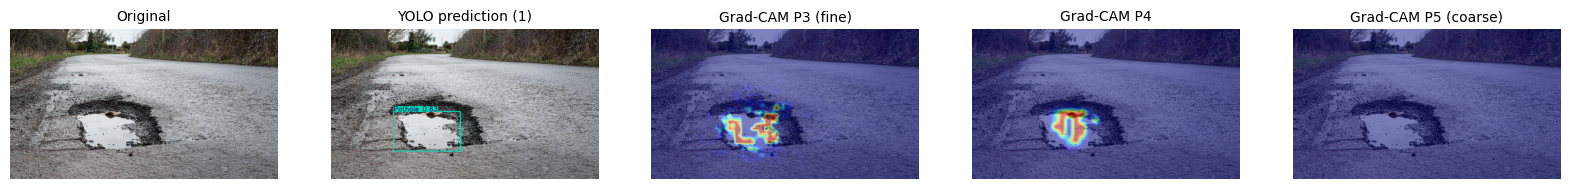

YOLO    : [('Pothole', 0.63)]
Severity: high (rule-based)
VLM     : Pothole - There is a large pothole in the middle of the road filled with water. | agrees with YOLO: True
1. Pothole (roughly 6 inches wide, bottom-center)
2. Agree with the detection.
3. Repair the pothole immediately to prevent further damage and ensure safe driving conditions.


{'tag': 'pothole_test_gradcam',
 'dets': [{'class': 'Pothole',
   'conf': 0.6325644850730896,
   'box': [478.2, 636.0, 989.0, 939.8],
   'position': 'bottom-center',
   'area_pct': 6.575064449387942}],
 'figure': '/content/drive/MyDrive/road_crack_detection/yolo26s_strip_vlm/gradcam/pothole_test_gradcam.png',
 'no_detection': False,
 'severity_rule': 'high',
 'main_detection': 'Pothole',
 'vlm_blind': 'Pothole - There is a large pothole in the middle of the road filled with water.',
 'vlm_agrees_with_yolo': True,
 'vlm_explanation': '1. Pothole (roughly 6 inches wide, bottom-center)\n2. Agree with the detection.\n3. Repair the pothole immediately to prevent further damage and ensure safe driving conditions.'}

In [20]:
analyze('/content/d0f412a0-e492-11f0-a06d-4903df3f724c.jpg', name='pothole_test')

In [24]:
from google.colab import files
uploaded = files.upload()
print(list(uploaded.keys()))

Saving transverse.jpg to transverse (1).jpg
['transverse (1).jpg']


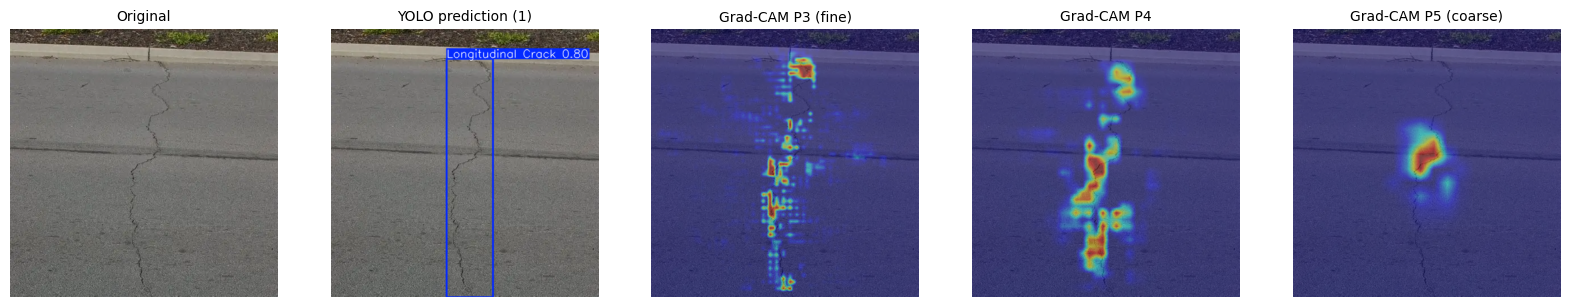

YOLO    : [('Longitudinal Crack', 0.8)]
Severity: high (rule-based)
VLM     : Longitudinal crack - The image shows a long, straight crack running through the asphalt. | agrees with YOLO: True
1. Visible damage (type, rough size, location): Longitudinal crack, approximately 15.4% of the image width, middle-center.
2. Detector check: Agree with the detection of a longitudinal crack. The detector missed any potential transverse cracks or other types of damage.
3. Recommended action: Repair the longitudinal crack to prevent further deterioration and ensure road safety.


{'tag': 'pothole_test_gradcam',
 'dets': [{'class': 'Longitudinal Crack',
   'conf': 0.7994986176490784,
   'box': [204.7, 54.2, 287.0, 476.0],
   'position': 'middle-center',
   'area_pct': 15.386509626624106}],
 'figure': '/content/drive/MyDrive/road_crack_detection/yolo26s_strip_vlm/gradcam/pothole_test_gradcam.png',
 'no_detection': False,
 'severity_rule': 'high',
 'main_detection': 'Longitudinal Crack',
 'vlm_blind': 'Longitudinal crack - The image shows a long, straight crack running through the asphalt.',
 'vlm_agrees_with_yolo': True,
 'vlm_explanation': '1. Visible damage (type, rough size, location): Longitudinal crack, approximately 15.4% of the image width, middle-center.\n2. Detector check: Agree with the detection of a longitudinal crack. The detector missed any potential transverse cracks or other types of damage.\n3. Recommended action: Repair the longitudinal crack to prevent further deterioration and ensure road safety.'}

In [26]:
analyze('/content/transverse (1).jpg', name='pothole_test')